# DiffBind: Differential Binding Analysis


In [1]:
library(DiffBind)
    library(DESeq2)
    library(ChIPseeker)
    library(GenomicFeatures)
    library(org.Mm.eg.db)
    library(ggplot2)
    library(dplyr)
    library(readr)
    library(tibble)

# --- change this to run a different factor ---
TF <- 'Fosb'   

# --- paths ---
MANIFEST  <- '../0_samplesheets/sample_manifest.tsv'
BAM_DIR   <- '../2_aligned'
PEAK_DIR  <- '../3_peaks'
GTF       <- '../igenomes/Mus_musculus/UCSC/mm10/Annotation/Genes/genes.gtf'
OUT_DIR   <- '0_outputs/'

PEAK_TYPE   <- "relaxed"
PEAK_SUFFIX <- paste0(".seacr.peaks.", PEAK_TYPE, ".bed")

# --- settings ---
TSS_UP     <- 3000    # bp upstream of TSS for promoter annotation
TSS_DOWN   <- 3000    # bp downstream of TSS for promoter annotation
FDR_THRESH <- 0.05

dir.create(OUT_DIR, showWarnings=FALSE)
cat('Running TF:', TF, '\n')

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loa

Running TF: Fosb 


In [2]:
manifest <- read_tsv(MANIFEST, show_col_types = FALSE)

build_samplesheet <- function(tf_manifest, bam_dir, peak_dir) {
    # nf-core names samples as {group}_R{replicate}, e.g. GFP_H3K4me3_R1
    nf_id <- paste0(tf_manifest$sample_name, '_R', sub('.*_', '', tf_manifest$sample_id))
    data.frame(
        SampleID   = tf_manifest$sample_id,
        Tissue     = tf_manifest$tf[1],
        Factor     = tf_manifest$tf[1],
        Condition  = tf_manifest$group,
        Replicate  = ave(tf_manifest$sample_id, tf_manifest$group, FUN = seq_along),
        bamReads   = file.path(bam_dir, paste0(nf_id, '.final.bam')),
        Peaks      = file.path(peak_dir, paste0(nf_id, PEAK_SUFFIX)),
        PeakCaller = 'bed',
        stringsAsFactors = FALSE
    )
}

In [3]:
tf_manifest <- manifest %>% filter(tf == TF)
ss <- build_samplesheet(tf_manifest, BAM_DIR, PEAK_DIR)

In [4]:
dba_obj <- dba(sampleSheet=ss)
dba_obj

GFP_Fosb_1 Fosb Fosb GFP  1 bed

GFP_Fosb_2 Fosb Fosb GFP  2 bed

GFP_Fosb_3 Fosb Fosb GFP  3 bed

GFP_Fosb_4 Fosb Fosb GFP  4 bed

TFF1_Fosb_1 Fosb Fosb TFF1  1 bed

TFF1_Fosb_2 Fosb Fosb TFF1  2 bed

TFF1_Fosb_3 Fosb Fosb TFF1  3 bed

TFF1_Fosb_4 Fosb Fosb TFF1  4 bed



8 Samples, 14233 sites in matrix (39856 total):
           ID Tissue Factor Condition Replicate Intervals
1  GFP_Fosb_1   Fosb   Fosb       GFP         1      5183
2  GFP_Fosb_2   Fosb   Fosb       GFP         2       875
3  GFP_Fosb_3   Fosb   Fosb       GFP         3     12172
4  GFP_Fosb_4   Fosb   Fosb       GFP         4      3241
5 TFF1_Fosb_1   Fosb   Fosb      TFF1         1     32606
6 TFF1_Fosb_2   Fosb   Fosb      TFF1         2      8047
7 TFF1_Fosb_3   Fosb   Fosb      TFF1         3      2873
8 TFF1_Fosb_4   Fosb   Fosb      TFF1         4     14889

In [6]:
# summits=FALSE keeps the SEACR IgG peak coordinates as-is
# Inspect: reads per sample, FRiP (fraction of reads in peaks)
dba_obj <- dba.count(dba_obj, summits=FALSE, bParallel=TRUE)
dba_obj

8 Samples, 293 sites in matrix:
           ID Tissue Factor Condition Replicate    Reads FRiP
1  GFP_Fosb_1   Fosb   Fosb       GFP         1 29048086 0.01
2  GFP_Fosb_2   Fosb   Fosb       GFP         2 24598658 0.01
3  GFP_Fosb_3   Fosb   Fosb       GFP         3 27495754 0.01
4  GFP_Fosb_4   Fosb   Fosb       GFP         4 31546070 0.01
5 TFF1_Fosb_1   Fosb   Fosb      TFF1         1 29434168 0.00
6 TFF1_Fosb_2   Fosb   Fosb      TFF1         2 31176926 0.00
7 TFF1_Fosb_3   Fosb   Fosb      TFF1         3 27020455 0.00
8 TFF1_Fosb_4   Fosb   Fosb      TFF1         4 25162120 0.00

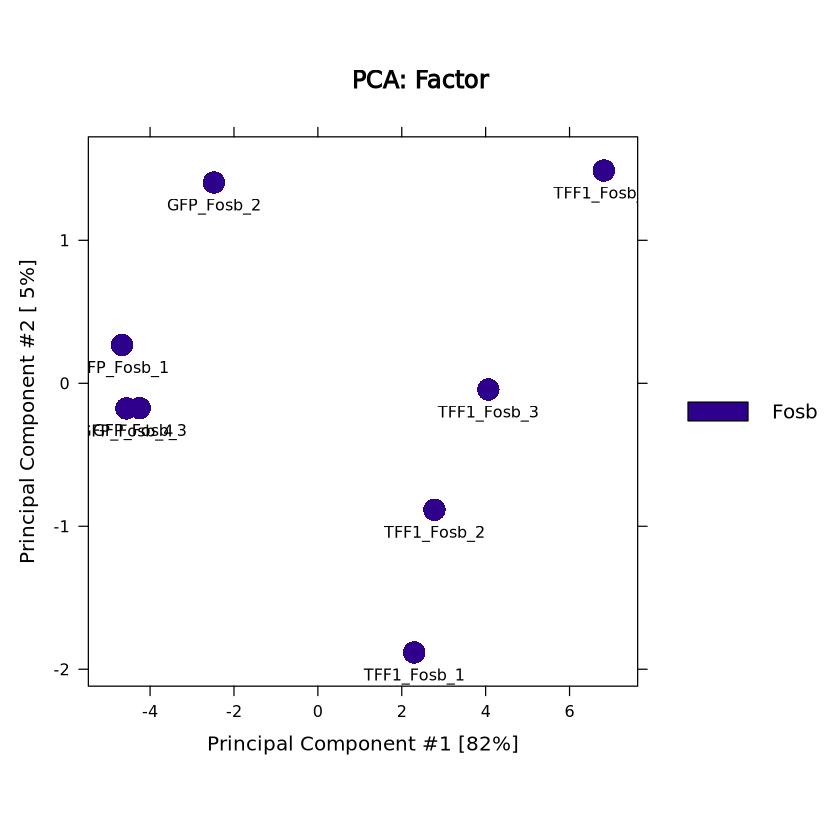

In [7]:
dba.plotPCA(dba_obj,  attributes=DBA_FACTOR, label=DBA_ID)

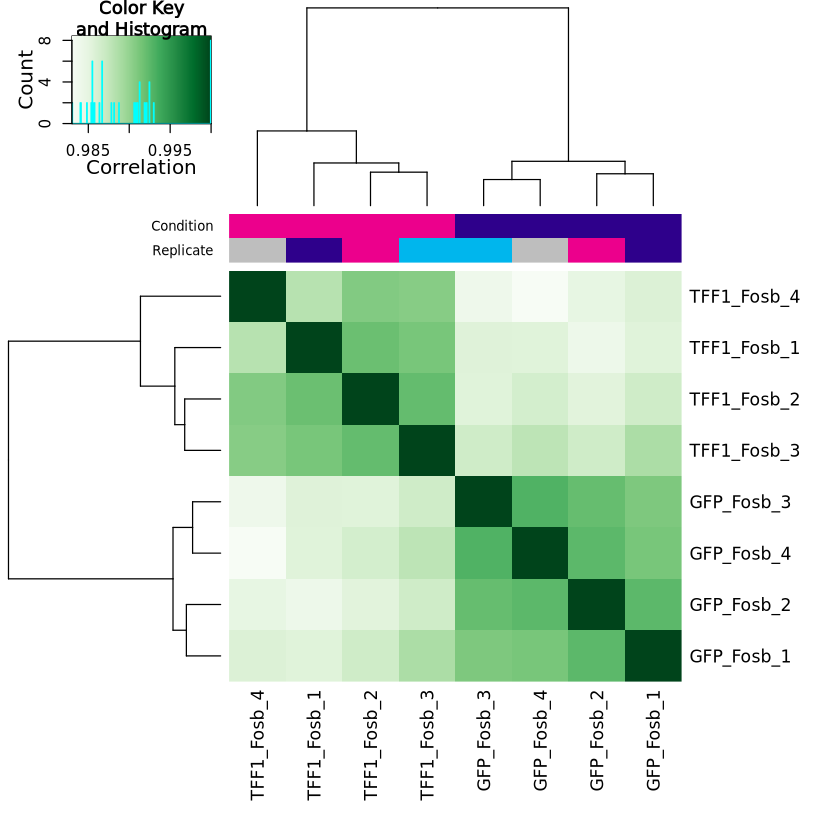

In [8]:
plot(dba_obj)

In [9]:
cts <- dba.peakset(dba_obj, bRetrieve=TRUE, DataType=DBA_DATA_FRAME)
cat('Peaks:', nrow(cts), '\n')
cat('Range of counts across peaks:\n')
print(summary(rowSums(cts[, -(1:3)])))
cat('Samples with zero total counts:\n')
print(colSums(cts[, -(1:3)]))

Peaks: 293 
Range of counts across peaks:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    421    1066    2298    4019    4669   57132 
Samples with zero total counts:
 GFP_Fosb_1  GFP_Fosb_2  GFP_Fosb_3  GFP_Fosb_4 TFF1_Fosb_1 TFF1_Fosb_2 
   176376.8    160588.1    171506.7    175588.0    131495.4    129909.2 
TFF1_Fosb_3 TFF1_Fosb_4 
   122925.2    109167.3 


In [10]:
dba_obj <- dba.normalize(dba_obj)

norm <- dba.normalize(dba_obj, bRetrieve=TRUE)
norm

$norm.method
[1] "lib"

$norm.factors
[1] 1.0306120 0.8727484 0.9755360 1.1192392 1.0443099 1.1061422 0.9586726
[8] 0.8927398

$lib.method
[1] "full"

$lib.sizes
[1] 29048086 24598658 27495754 31546070 29434168 31176926 27020455 25162120

$control.subtract
[1] TRUE

$filter.value
[1] 1

In [11]:
info <- dba.show(dba_obj)
normlibs <- cbind(FullLibSize=norm$lib.sizes, NormFacs=norm$norm.factors,
                  NormLibSize=round(norm$lib.sizes/norm$norm.factors))

rownames(normlibs) <- info$ID
normlibs

,FullLibSize,NormFacs,NormLibSize
GFP_Fosb_1,29048086,1.0306120,28185280
GFP_Fosb_2,24598658,0.8727484,28185280
GFP_Fosb_3,27495754,0.9755360,28185280
GFP_Fosb_4,31546070,1.1192392,28185280
TFF1_Fosb_1,29434168,1.0443099,28185280
TFF1_Fosb_2,31176926,1.1061422,28185280
TFF1_Fosb_3,27020455,0.9586726,28185280
TFF1_Fosb_4,25162120,0.8927398,28185280


In [12]:
# positive Fold = TFF1-enriched, negative = GFP-enriched
dba_obj <- dba.contrast(
    dba_obj,
    group1 = dba.mask(dba_obj, DBA_CONDITION, 'TFF1'),
    group2 = dba.mask(dba_obj, DBA_CONDITION, 'GFP'),
    name1  = 'TFF1',
    name2  = 'GFP'
)

dba_obj

8 Samples, 293 sites in matrix:
           ID Tissue Factor Condition Replicate    Reads FRiP
1  GFP_Fosb_1   Fosb   Fosb       GFP         1 29048086 0.01
2  GFP_Fosb_2   Fosb   Fosb       GFP         2 24598658 0.01
3  GFP_Fosb_3   Fosb   Fosb       GFP         3 27495754 0.01
4  GFP_Fosb_4   Fosb   Fosb       GFP         4 31546070 0.01
5 TFF1_Fosb_1   Fosb   Fosb      TFF1         1 29434168 0.00
6 TFF1_Fosb_2   Fosb   Fosb      TFF1         2 31176926 0.00
7 TFF1_Fosb_3   Fosb   Fosb      TFF1         3 27020455 0.00
8 TFF1_Fosb_4   Fosb   Fosb      TFF1         4 25162120 0.00

1 Contrast:
  Group Samples Group2 Samples2
1  TFF1       4    GFP        4

In [13]:
#dba_obj$config$th <- 0.5

In [14]:
dba_obj <- dba.analyze(dba_obj)

dba.show(dba_obj, bContrasts=TRUE)

Applying Blacklist/Greylists...

Genome detected: Mmusculus.UCSC.mm10

Applying blacklist...

Removed: 1 of 293 intervals.

Re-normalizing...

Removed 1 (of 293) consensus peaks.

Analyzing...

converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



,Group,Samples,Group2,Samples2,DB.DESeq2
,<chr>,<chr>,<chr>,<chr>,<chr>
1,TFF1,4,GFP,4,247


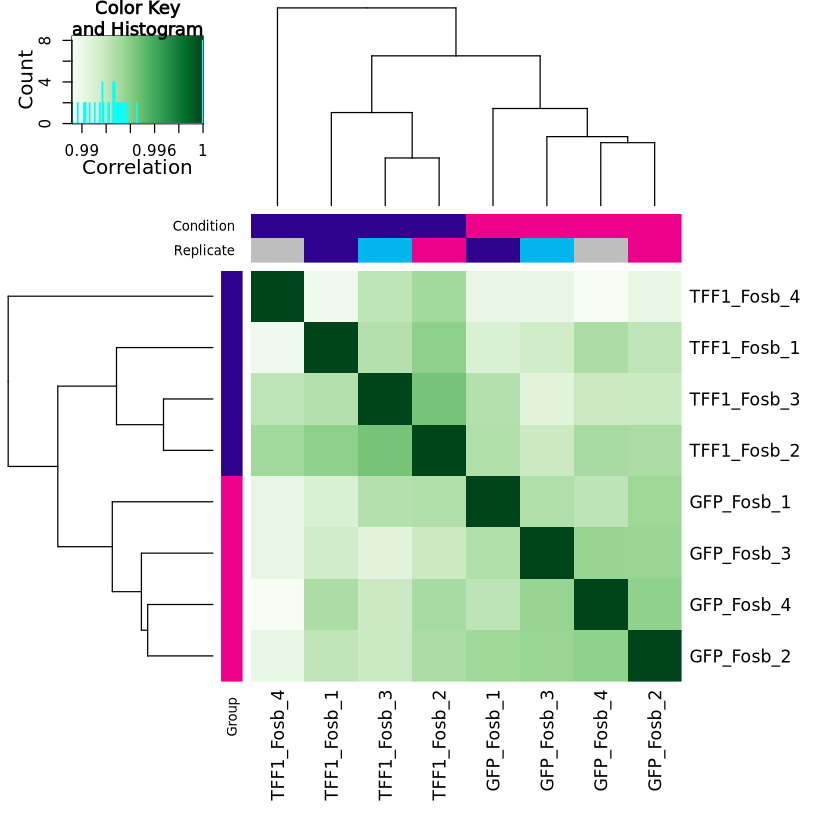

In [15]:
plot(dba_obj, contrast = 1)

In [16]:
dba_obj.DB <- dba.report(dba_obj)
dba_obj.DB

GRanges object with 247 ranges and 6 metadata columns:
      seqnames              ranges strand |      Conc Conc_TFF1  Conc_GFP
         <Rle>           <IRanges>  <Rle> | <numeric> <numeric> <numeric>
   32     chr4 130236300-130284550      * |  10.17384   9.76959   10.4893
   70     chr4 134999750-135081200      * |  10.89935  10.62877   11.1271
  207     chr4 152006300-152048600      * |  10.00112   9.68969   10.2571
   59     chr4 133393800-133430850      * |   9.81244   9.50433   10.0662
  177     chr4 148922100-148990350      * |  10.71688  10.42296   10.9609
  ...      ...                 ...    ... .       ...       ...       ...
  276     chr9   21243150-21246250      * |   6.19053   5.93258   6.40928
  279     chr9   64624750-64631100      * |   7.05166   6.89540   7.19264
  263     chr7   16920700-16925000      * |   6.66789   6.49500   6.82226
  259     chr5 135959350-135963650      * |   6.59970   6.40039   6.77479
   10    chr17   24564100-24567000      * |   6.09771   5

In [17]:
sum(dba_obj.DB$Fold>0)

[1] 2

In [18]:
sum(dba_obj.DB$Fold<0)

[1] 245

In [19]:
# Extract results — th=1 returns all peaks regardless of FDR
res_deseq2 <- dba.report(dba_obj, method=DBA_DESEQ2, th=1)
#res_edger  <- dba.report(dba_obj, method=DBA_EDGER,  th=1)

cat('--- DESeq2 ---\n')
print(head(as.data.frame(res_deseq2)))

sig_d <- res_deseq2[!is.na(res_deseq2$FDR) & res_deseq2$FDR < FDR_THRESH]

cat(sprintf('\nDESeq2: %d total | %d sig | %d TFF1 | %d GFP\n',
    length(res_deseq2), length(sig_d), sum(sig_d$Fold > 0), sum(sig_d$Fold < 0)))

#write.csv(as.data.frame(res_deseq2), file.path(OUT_DIR, paste0(TF, '_deseq2_results.csv')), row.names=FALSE)

# Save significant peak BED files (0-based start)
save_bed <- function(gr, path) {
    if (length(gr) > 0)
        write.table(data.frame(chr=seqnames(gr), start=start(gr)-1L, end=end(gr)),
                    path, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
}
save_bed(sig_d[sig_d$Fold > 0], file.path(OUT_DIR, paste0(TF, '_deseq2_TFF1_enriched.bed')))
save_bed(sig_d[sig_d$Fold < 0], file.path(OUT_DIR, paste0(TF, '_deseq2_GFP_enriched.bed')))

--- DESeq2 ---
    seqnames     start       end  width strand      Conc Conc_TFF1 Conc_GFP
32      chr4 130236300 130284550  48251      * 10.173837  9.769587 10.48925
70      chr4 134999750 135081200  81451      * 10.899351 10.628768 11.12711
207     chr4 152006300 152048600  42301      * 10.001116  9.689691 10.25711
59      chr4 133393800 133430850  37051      *  9.812439  9.504329 10.06619
177     chr4 148922100 148990350  68251      * 10.716876 10.422963 10.96093
230     chr4 154194500 154303000 108501      * 11.419062 11.124803 11.66335
          Fold      p.value          FDR
32  -0.7196668 8.531979e-27 2.491338e-24
70  -0.4983439 2.734952e-16 3.039797e-14
207 -0.5674143 3.123079e-16 3.039797e-14
59  -0.5618586 7.956292e-15 5.808093e-13
177 -0.5379643 1.408562e-14 8.226000e-13
230 -0.5385471 1.979739e-14 8.500010e-13

DESeq2: 292 total | 247 sig | 2 TFF1 | 245 GFP


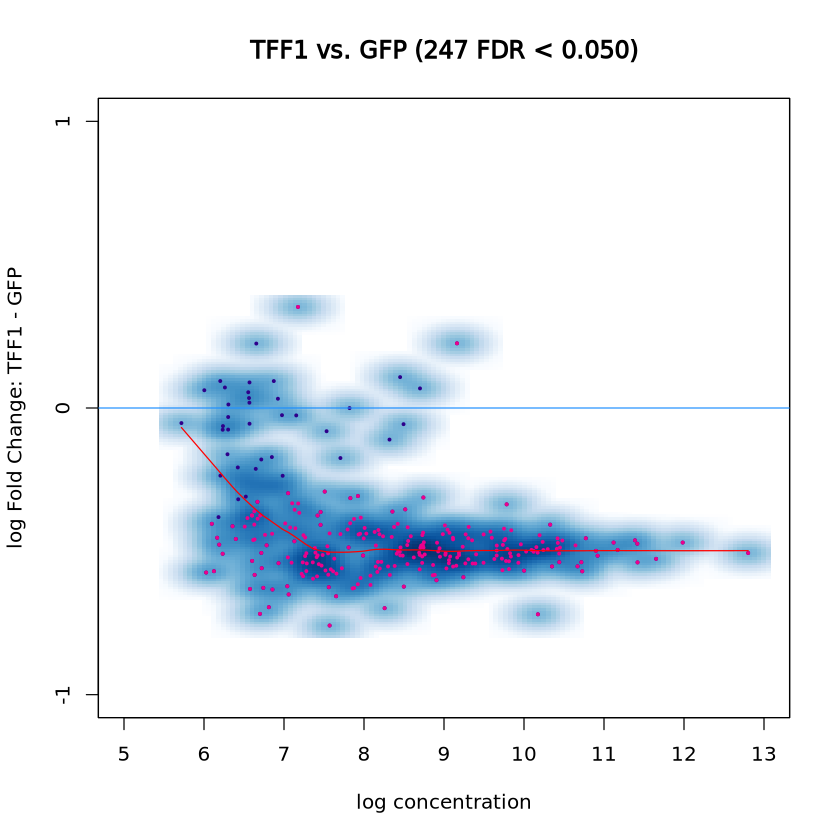

In [20]:
dba.plotMA(dba_obj, method=DBA_DESEQ2)

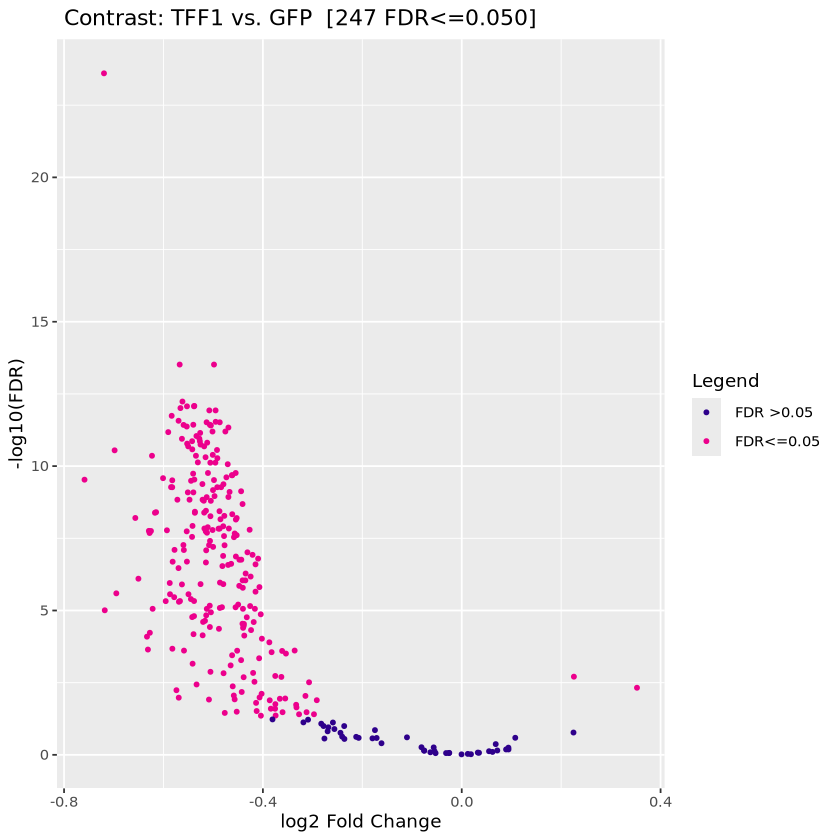

In [21]:
dba.plotVolcano(dba_obj, method=DBA_DESEQ2)

In [22]:
txdb <- makeTxDbFromGFF(GTF, format='gtf')

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
OK



In [24]:
# Annotate all peaks from DESeq2 and edgeR output (th=1, includes non-significant)
# ChIPseeker: TSS window defined in the settings cell (TSS_UP / TSS_DOWN)

annotate_gr <- function(gr, txdb, tss_up, tss_down) {
    anno <- annotatePeak(
        gr,
        TxDb      = txdb,
        tssRegion = c(-tss_up, tss_down),
        annoDb    = 'org.Mm.eg.db'
    )
    df <- as.data.frame(anno)
    names(df)[names(df) == 'p-value'] <- 'pvalue'
    df
}

anno_d <- annotate_gr(res_deseq2, txdb, TSS_UP, TSS_DOWN)

tag <- function(df) {
    df$significant <- !is.na(df$FDR) & df$FDR < FDR_THRESH
    df$direction   <- ifelse(!df$significant, 'NS',
                      ifelse(df$Fold > 0, 'TFF1', 'GFP'))
    df
}
anno_d <- tag(anno_d)

#write.csv(anno_d, file.path(OUT_DIR, paste0(TF, '_deseq2_annotated.csv')), row.names=FALSE)

cat(sprintf('DESeq2: %d total peaks annotated (%d sig)\n', nrow(anno_d), sum(anno_d$significant)))

cat('Annotation columns:', paste(names(anno_d), collapse=', '), '\n\n')
preview_cols <- intersect(
    c('seqnames', 'start', 'end', 'Fold', 'FDR', 'annotation', 'SYMBOL', 'distanceToTSS'),
    names(anno_d)
)
head(anno_d[, preview_cols])

>> preparing features information...		 2026-04-13 12:33:35 
>> identifying nearest features...		 2026-04-13 12:33:35 
>> calculating distance from peak to TSS...	 2026-04-13 12:33:35 
>> assigning genomic annotation...		 2026-04-13 12:33:35 
>> adding gene annotation...			 2026-04-13 12:33:35 


Warning message in annotatePeak(gr, TxDb = txdb, tssRegion = c(-tss_up, tss_down), :
“Unknown ID type, gene annotation will not be added...”


>> assigning chromosome lengths			 2026-04-13 12:33:35 
>> done...					 2026-04-13 12:33:35 
DESeq2: 292 total peaks annotated (247 sig)
Annotation columns: seqnames, start, end, width, strand, Conc, Conc_TFF1, Conc_GFP, Fold, p.value, FDR, annotation, geneChr, geneStart, geneEnd, geneLength, geneStrand, geneId, transcriptId, distanceToTSS, significant, direction 



,seqnames,start,end,Fold,FDR,annotation,distanceToTSS
,<fct>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
1,chr4,130236300,130284550,-0.7196668,2.491338e-24,Promoter (<=1kb),0
2,chr4,134999750,135081200,-0.4983439,3.039797e-14,Distal Intergenic,-39445
3,chr4,152006300,152048600,-0.5674143,3.039797e-14,Promoter (<=1kb),0
4,chr4,133393800,133430850,-0.5618586,5.808093e-13,3' UTR,24024
5,chr4,148922100,148990350,-0.5379643,8.226000e-13,3' UTR,109462
6,chr4,154194500,154303000,-0.5385471,8.500010e-13,Promoter (<=1kb),0


>> preparing features information...		 2026-03-11 12:35:09 
>> identifying nearest features...		 2026-03-11 12:35:09 
>> calculating distance from peak to TSS...	 2026-03-11 12:35:10 
>> assigning genomic annotation...		 2026-03-11 12:35:10 
>> assigning chromosome lengths			 2026-03-11 12:35:11 
>> done...					 2026-03-11 12:35:11 
>> preparing features information...		 2026-03-11 12:35:11 
>> identifying nearest features...		 2026-03-11 12:35:11 
>> calculating distance from peak to TSS...	 2026-03-11 12:35:12 
>> assigning genomic annotation...		 2026-03-11 12:35:12 
>> assigning chromosome lengths			 2026-03-11 12:35:13 
>> done...					 2026-03-11 12:35:13 


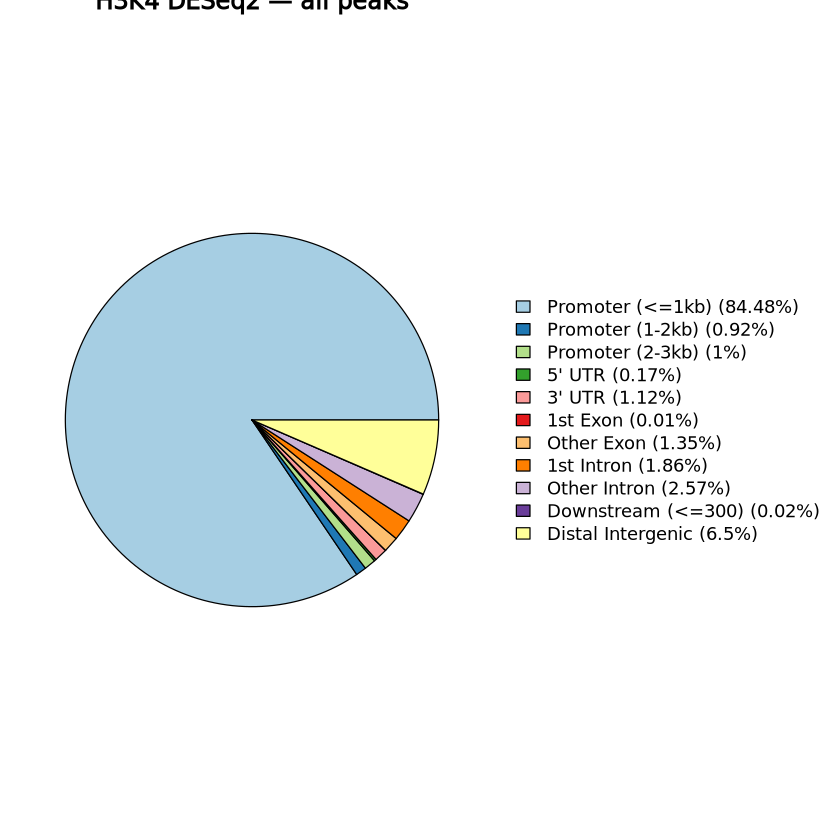

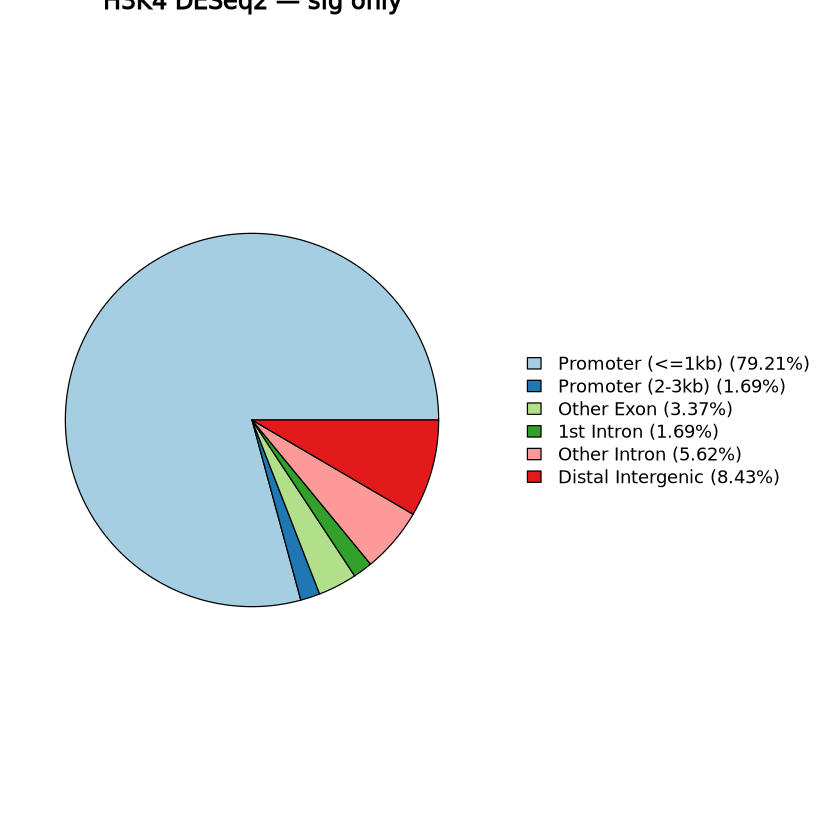

In [22]:

plot_pies <- function(gr_all, gr_sig, label, txdb, tss_up, tss_down) {
    anno_all <- annotatePeak(gr_all, TxDb=txdb, tssRegion=c(-tss_up, tss_down))
    if (length(gr_sig) > 0) {
        par(mfrow=c(1,2))
        plotAnnoPie(anno_all, main=paste(TF, label, '— all peaks'))
        anno_sig <- annotatePeak(gr_sig, TxDb=txdb, tssRegion=c(-tss_up, tss_down))
        plotAnnoPie(anno_sig, main=paste(TF, label, '— sig only'))
    } else {
        par(mfrow=c(1,1))
        plotAnnoPie(anno_all, main=paste(TF, label, '— all peaks (0 sig)'))
    }
}

plot_pies(res_deseq2, sig_d, 'DESeq2', txdb, TSS_UP, TSS_DOWN)

In [25]:
tff1_sig  <- anno_d[!is.na(anno_d$direction) & anno_d$direction == 'TFF1',  ]
gfp_sig <- anno_d[!is.na(anno_d$direction) & anno_d$direction == 'GFP', ]

write.csv(anno_d,    file.path(OUT_DIR, paste0(TF, '_deseq2_all_results.csv')),    row.names=FALSE)
write.csv(tff1_sig,  file.path(OUT_DIR, paste0(TF, '_deseq2_tff1_enriched.csv')),  row.names=FALSE)
write.csv(gfp_sig, file.path(OUT_DIR, paste0(TF, '_deseq2_gfp_enriched.csv')), row.names=FALSE)

cat(sprintf('Saved CSVs to %s/\n  All: %d | TFF1-enriched: %d | GFP-enriched: %d\n',
    OUT_DIR, nrow(anno_d), nrow(tff1_sig), nrow(gfp_sig)))

Saved CSVs to 0_outputs//
  All: 292 | TFF1-enriched: 2 | GFP-enriched: 245
